<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


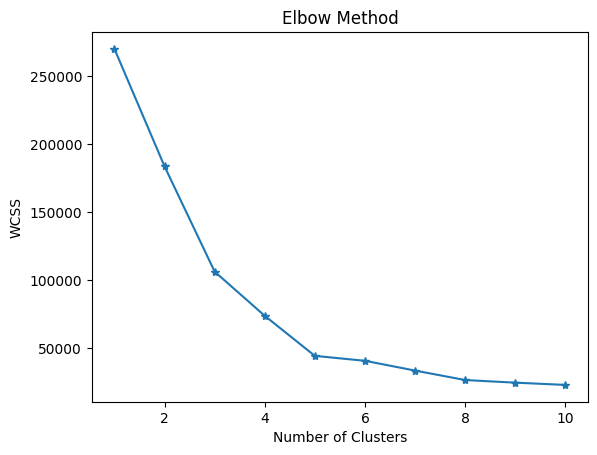

ValueError: x and y must be the same size

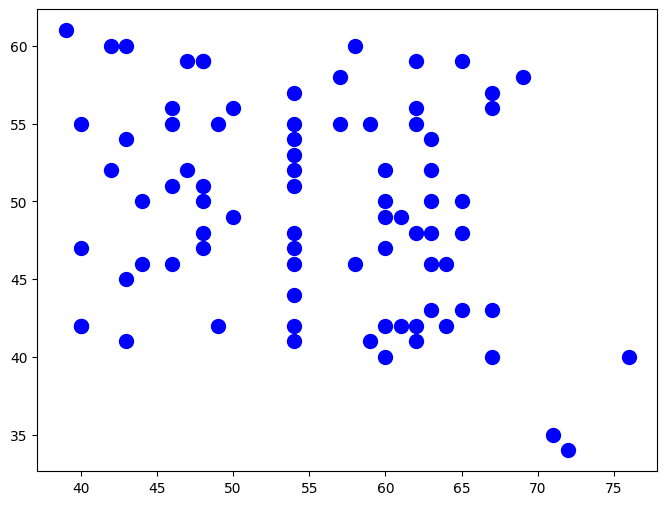

In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Load dataset
df = pd.read_csv('/content/Mall_Customers.csv')

df.info()
df.describe()
df.isnull().sum()
# Display dataset
print(df.head())

# Select features
x = df.iloc[:, [3, 4]].values

# Elbow Method
wcss_list = []

for i in range(1, 11):
    kmeans_model = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42
    )

    kmeans_model.fit(x)
    wcss_list.append(kmeans_model.inertia_)

# Plot Elbow graph
plt.plot(range(1, 11), wcss_list, marker='*')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

# Create K-Means model
kmeans_model = KMeans(
    n_clusters=5,
    init='k-means++',
    random_state=42
)

# Train model and predict clusters
y_pred = kmeans_model.fit_predict(x)

# Visualize clusters
plt.figure(figsize=(8, 6))

plt.scatter(x[y_pred == 0, 0], x[y_pred == 0, 1],
            s=100, c='blue', label='Cluster 1')

plt.scatter(x[y_pred == 0, 1], x[y_pred == 1, 1],
            s=100, c='green', label='Cluster 2')

plt.scatter(x[y_pred == 0, 2], x[y_pred == 1, 2],
            s=100, c='red', label='Cluster 3')

plt.scatter(x[y_pred == 0, 3], x[y_pred == 1, 3],
            s=100, c='cyan', label='Cluster 4')

plt.scatter(x[y_pred == 0, 4], x[y_pred == 1, 4],
            s=100, c='black', label='Cluster 5')

# Plot centroids
plt.scatter(
    kmeans_model.cluster_centers_[:, 0],
    kmeans_model.cluster_centers_[:, 1],
    s=300,
    c='yellow',
    label='Centroids'
)

# Add labels and title
plt.title('Clusters of Customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

In [ ]:
https://github.com/sakshichitti87-del/CIE-EXAMS/blob/main/CIE_4.ipynb